# CREMA-D Spectrogram Generation

Trims silence from WAV files and generates grayscale mel-spectrogram PNGs for CNN training.

**Prerequisites:** Run `crema_d_prep.ipynb` first to create the `data/` train/test split.

**Output:** PNGs are written alongside their WAV files in `data/{train,test}/{emotion}/`, compatible with PyTorch `ImageFolder` / Keras `image_dataset_from_directory`.

Run all cells top-to-bottom from the **repo root directory**.

In [67]:
from pathlib import Path
import numpy as np

REPO_ROOT = Path.cwd().resolve()
INPUT_DIR = REPO_ROOT / "data"

# Spectrogram parameters
SR = 16000          # sample rate
N_FFT = 2048        # FFT window size
HOP_LENGTH = 64     # hop length
N_MELS = 512        # mel bands
TOP_DB = 20         # silence trim threshold (dB)

# Output image dimensions
IMG_WIDTH = 640
IMG_HEIGHT = 640
DPI = 300

# Parallel conversion — tune to your machine (logical CPU count is a good starting point)
MAX_WORKERS = 8

EMOTIONS = ["ANG", "DIS", "FEA", "HAP", "NEU", "SAD"]

assert INPUT_DIR.exists(), f"data/ not found at {INPUT_DIR}. Run crema_d_prep.ipynb first."
print(f"Data dir: {INPUT_DIR}")
print(f"Workers: {MAX_WORKERS}")

Data dir: /Users/velu/Documents/github/crema-d-mirror/data
Workers: 8


In [68]:
import subprocess, sys
for pkg in ["librosa", "matplotlib", "soundfile"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import matplotlib
matplotlib.use("Agg")  # non-interactive backend; required for thread safety in batch mode

import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile  # backend for librosa, not used directly
import concurrent.futures
print(f"librosa {librosa.__version__}")

librosa 0.11.0


## Helper: WAV → mel-spectrogram PNG

Loads a WAV, trims leading/trailing silence, computes a mel-spectrogram, and saves as a grayscale PNG at the configured resolution. Returns durations for inspection.

In [69]:
def wav_to_spectrogram_png(wav_path, png_path, trim=True):
    """Convert a WAV file to a grayscale mel-spectrogram PNG.

    Returns (original_duration, trimmed_duration) in seconds.
    trimmed_duration equals original_duration when trim=False.
    """
    y, sr_loaded = librosa.load(wav_path, sr=SR)
    original_duration = len(y) / sr_loaded

    if trim:
        y, _ = librosa.effects.trim(y, top_db=TOP_DB)
    trimmed_duration = len(y) / sr_loaded

    S = librosa.feature.melspectrogram(y=y, sr=sr_loaded,
                                        n_fft=N_FFT, hop_length=HOP_LENGTH,
                                        n_mels=N_MELS)
    S_db = librosa.power_to_db(S, ref=np.max)

    fig, ax = plt.subplots(1, 1, figsize=(IMG_WIDTH / DPI, IMG_HEIGHT / DPI), dpi=DPI)
    ax.imshow(S_db, aspect="auto", origin="lower", cmap="gray")
    ax.axis("off")
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

    return original_duration, trimmed_duration

## Sample trial

Run the helper on one clip to visually verify the spectrogram parameters and trim threshold.
This is the only cell that displays a spectrogram inline — adjust config values above and re-run if needed.

File: 1001_DFA_ANG_XX.wav
Original duration: 2.28s
Trimmed duration:  1.12s
Removed:           1.16s


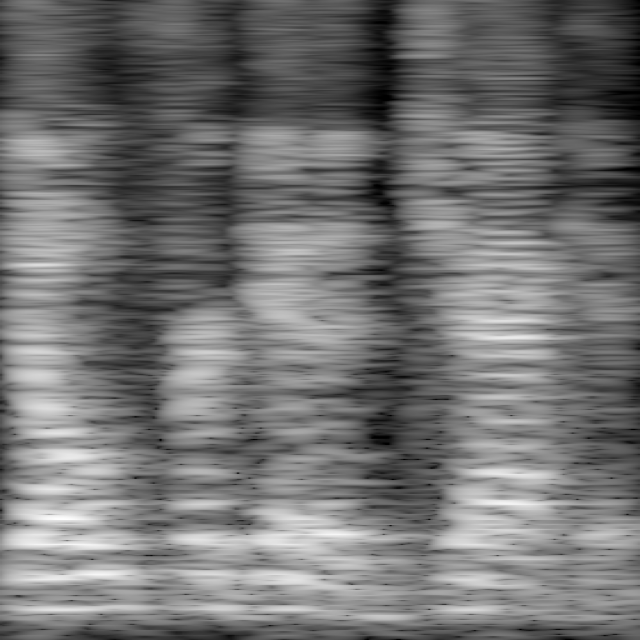

In [70]:
# Pick the first WAV in train/ANG as a sample
sample_dir = INPUT_DIR / "train" / "ANG"
sample_wav = sorted(sample_dir.glob("*.wav"))[0]
sample_png = sample_dir / "_sample_trial.png"

orig_dur, trim_dur = wav_to_spectrogram_png(sample_wav, sample_png)

print(f"File: {sample_wav.name}")
print(f"Original duration: {orig_dur:.2f}s")
print(f"Trimmed duration:  {trim_dur:.2f}s")
print(f"Removed:           {orig_dur - trim_dur:.2f}s")

from IPython.display import Image, display
display(Image(filename=str(sample_png), width=IMG_WIDTH, height=IMG_HEIGHT))

# Clean up trial file
sample_png.unlink()

## Batch conversion

Convert all WAV files to mel-spectrogram PNGs. Progress is printed per emotion directory.
On error (corrupt/empty WAV), the filename is logged and processing continues.

In [71]:
def _convert_one(args):
    """Worker function: convert one WAV to PNG. Skips if PNG already exists and is non-empty."""
    wav_path, png_path = args
    if png_path.exists() and png_path.stat().st_size > 0:
        return "skipped", str(wav_path), None
    try:
        wav_to_spectrogram_png(wav_path, png_path)
        return "ok", str(wav_path), None
    except Exception as e:
        return "fail", str(wav_path), str(e)


failures = []

for split in ["train", "test"]:
    for emo in EMOTIONS:
        emo_dir = INPUT_DIR / split / emo

        wavs = sorted(emo_dir.glob("*.wav"))
        tasks = [(w, emo_dir / f"{w.stem}.png") for w in wavs]

        counts = {"ok": 0, "skipped": 0, "fail": 0}
        with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            for status, path, err in executor.map(_convert_one, tasks):
                counts[status] += 1
                if status == "fail":
                    failures.append((path, err))

        print(f"{split}/{emo}: {counts['ok']} new, {counts['skipped']} skipped, "
              f"{counts['fail']} failed / {len(wavs)} total")

print(f"\nDone. Total failures: {len(failures)}")
if failures:
    print("\nFailed files:")
    for path, err in failures:
        print(f"  {path}: {err}")

train/ANG: 1006 new, 0 skipped, 0 failed / 1006 total
train/DIS: 1006 new, 0 skipped, 0 failed / 1006 total
train/FEA: 1006 new, 0 skipped, 0 failed / 1006 total
train/HAP: 1006 new, 0 skipped, 0 failed / 1006 total
train/NEU: 860 new, 0 skipped, 0 failed / 860 total
train/SAD: 1006 new, 0 skipped, 0 failed / 1006 total
test/ANG: 265 new, 0 skipped, 0 failed / 265 total
test/DIS: 265 new, 0 skipped, 0 failed / 265 total
test/FEA: 265 new, 0 skipped, 0 failed / 265 total
test/HAP: 265 new, 0 skipped, 0 failed / 265 total
test/NEU: 227 new, 0 skipped, 0 failed / 227 total
test/SAD: 265 new, 0 skipped, 0 failed / 265 total

Done. Total failures: 0


## Sanity checks

Verify PNG counts match WAV counts and files are non-trivial.

In [72]:
print(f"{'Split':<8} {'Emotion':<8} {'WAVs':>6} {'PNGs':>6} {'Match':>6}")
print("-" * 40)
all_ok = True
for split in ["train", "test"]:
    for emo in EMOTIONS:
        emo_dir = INPUT_DIR / split / emo
        n_wav = len(list(emo_dir.glob("*.wav")))
        n_png = len(list(emo_dir.glob("*.png")))
        match = "OK" if n_wav == n_png else "FAIL"
        if match == "FAIL":
            all_ok = False
        print(f"{split:<8} {emo:<8} {n_wav:>6} {n_png:>6} {match:>6}")

# Spot-check file sizes
sample_pngs = list((INPUT_DIR / "train" / "ANG").glob("*.png"))[:5]
print(f"\nSample PNG sizes (bytes):")
for p in sample_pngs:
    print(f"  {p.name}: {p.stat().st_size:,}")

total_png = len(list(INPUT_DIR.glob("*/*/*.png")))
print(f"\nTotal PNGs: {total_png}")
assert all_ok, "WAV/PNG count mismatch detected!"
print("All checks passed.")

Split    Emotion    WAVs   PNGs  Match
----------------------------------------
train    ANG        1006   1006     OK
train    DIS        1006   1006     OK
train    FEA        1006   1006     OK
train    HAP        1006   1006     OK
train    NEU         860    860     OK
train    SAD        1006   1006     OK
test     ANG         265    265     OK
test     DIS         265    265     OK
test     FEA         265    265     OK
test     HAP         265    265     OK
test     NEU         227    227     OK
test     SAD         265    265     OK

Sample PNG sizes (bytes):
  1084_TSI_ANG_XX.png: 203,741
  1069_IOM_ANG_XX.png: 179,246
  1091_TSI_ANG_XX.png: 180,993
  1050_TIE_ANG_XX.png: 185,627
  1045_TIE_ANG_XX.png: 214,267

Total PNGs: 7442
All checks passed.
